# Conditional Autoencoder for Asset Pricing - Part 2: The Model

This notebook uses a dataset created using `yfinance` in the notebook [conditional_autoencoder_for_asset_pricing_data](05_conditional_autoencoder_for_asset_pricing_data.ipynb). The results will vary depending on which ticker downloads succeeded.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import sys, os
from time import time
from pathlib import Path
from itertools import product
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dot, Reshape, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard

from sklearn.preprocessing import quantile_transform

from scipy.stats import spearmanr

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [4]:
sys.path.append(os.path.dirname(os.getcwd()))
from utils import MultipleTimeSeriesCV, format_time

In [5]:
idx = pd.IndexSlice
sns.set_style("whitegrid")
np.random.seed(42)

In [6]:
results_path = Path("results", "asset_pricing")
if not results_path.exists():
    results_path.mkdir(parents=True)

In [7]:
characteristics = [
    "beta",
    "betasq",
    "chmom",
    "dolvol",
    "idiovol",
    "ill",
    "indmom",
    "maxret",
    "mom12m",
    "mom1m",
    "mom36m",
    "mvel",
    "retvol",
    "turn",
    "turn_std",
]

## Load Data

In [8]:
with pd.HDFStore(results_path / "autoencoder.h5") as store:
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: results\asset_pricing\autoencoder.h5
/close                      frame        (shape->[7558,1662]) 
/factor/beta                frame        (shape->[1021992,1]) 
/factor/betasq              frame        (shape->[1021992,1]) 
/factor/chmom               frame        (shape->[1167218,1]) 
/factor/dolvol              frame        (shape->[1236566,1]) 
/factor/idiovol             frame        (shape->[1021992,1]) 
/factor/ill                 frame        (shape->[1023162,1]) 
/factor/indmom              frame        (shape->[1236699,1]) 
/factor/maxret              frame        (shape->[1236566,1]) 
/factor/mom12m              frame        (shape->[1167218,1]) 
/factor/mom1m               series       (shape->[1243426])   
/factor/mom36m              frame        (shape->[1021243,1]) 
/factor/mvel                frame        (shape->[1250697,1]) 
/factor/retvol              frame        (shape->[1243426,1]) 
/factor/turn                fram

### Weekly returns

In [9]:
data = (
    pd.read_hdf(results_path / "autoencoder.h5", "returns")
    .stack(dropna=False)
    .to_frame("returns")
    .loc[idx["1993":, :], :]
)

In [10]:
with pd.HDFStore(results_path / "autoencoder.h5") as store:
    keys = [k[1:] for k in store.keys() if k[1:].startswith("factor")]
    for key in keys:
        data[key.split("/")[-1]] = store[key].squeeze()

In [11]:
data

returns      beta    betasq     chmom     dolvol  \
date       ticker                                                      
1993-01-01 AAL          NaN       NaN       NaN       NaN        NaN   
           AAME   -0.133333  1.175500  1.381801  0.158730   9.497200   
           AAOI         NaN       NaN       NaN       NaN        NaN   
           AAON    0.076925       NaN       NaN       NaN        NaN   
           AAPL    0.012711  1.445569  2.089669  0.511178  17.956744   
...                     ...       ...       ...       ...        ...   
2020-01-03 ZTEK   -0.035714  0.396138  0.156925  0.068965   7.330655   
           ZUMZ    0.039486  1.076804  1.159508 -0.031559  16.122426   
           ZVRA    0.004785  1.640438  2.691037 -0.690368  11.652303   
           ZYME    0.004479       NaN       NaN  0.268181  16.499085   
           ZYXI   -0.011180  0.302258  0.091360 -2.887022  14.826201   

                    idiovol           ill    indmom    maxret    mom12m  \
date       ticker                                                         
1993-01-01 AAL          NaN           NaN       NaN       NaN       NaN   
           AAME    0.158116           NaN  0.446345  1.133333  1.285714   
           AAOI         NaN           NaN       NaN       NaN       NaN   
           AAON         NaN           NaN  0.358162       NaN       NaN   
           AAPL    0.050371  2.364369e-10  0.330293  0.108122 -0.004098   
...                     ...           ...       ...       ...       ...   
2020-01-03 ZTEK    0.076970           NaN  0.242010  0.071429  0.000000   
           ZUMZ    0.062520  1.203386e-09  0.174283  0.121489  0.617044   
           ZVRA    0.101721  4.150525e-07  0.242010 -0.066667 -0.750000   
           ZYME         NaN  1.643219e-09  0.242010  0.316918  2.146520   
           ZYXI    0.099939  1.357906e-08  0.242010  0.165372  3.170542   

                      mom1m    mom36m       mvel    retvol      turn  turn_std  
date       ticker                                                               
1993-01-01 AAL          NaN       NaN        NaN       NaN       NaN       NaN  
           AAME   -0.187500 -0.631579  17.394230  0.067069  0.000380  0.000363  
           AAOI         NaN       NaN        NaN       NaN       NaN       NaN  
           AAON         NaN       NaN  16.585699       NaN       NaN       NaN  
           AAPL    0.025751  0.597130  23.636890  0.016107  0.010556  0.004435  
...                     ...       ...        ...       ...       ...       ...  
2020-01-03 ZTEK   -0.068965 -0.532258  18.272149  0.043877  0.000042  0.000062  
           ZUMZ    0.104749 -0.113753  19.280069  0.042489  0.025551  0.031467  
           ZVRA   -0.066667 -0.462687  20.226199  0.090539  0.000393  0.001034  
           ZYME    0.044237       NaN  20.662236  0.028993  0.004572  0.002586  
           ZYXI   -0.260223  7.281254  17.465607  0.040876  0.014565  0.006623  

[2343420 rows x 16 columns]

In [12]:
characteristics = data.drop("returns", axis=1).columns.tolist()

In [13]:
data["returns_fwd"] = data.returns.unstack("ticker").shift(-1).stack()

In [14]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2343420 entries, (Timestamp('1993-01-01 00:00:00'), 'AAL') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 17 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   returns      1208156 non-null  float64
 1   beta         1021992 non-null  float64
 2   betasq       1021992 non-null  float64
 3   chmom        1141228 non-null  float64
 4   dolvol       1197840 non-null  float64
 5   idiovol      1021992 non-null  float64
 6   ill          1000373 non-null  float64
 7   indmom       1208156 non-null  float64
 8   maxret       1197840 non-null  float64
 9   mom12m       1141228 non-null  float64
 10  mom1m        1203484 non-null  float64
 11  mom36m       1021243 non-null  float64
 12  mvel         1209512 non-null  float64
 13  retvol       1203484 non-null  float64
 14  turn         1192041 non-null  float64
 15  turn_std     1203844 non-null  float64
 16  returns_fwd  12

In [17]:
nobs_by_date = data.groupby(level="date").count().max(1)
nobs_by_characteristic = pd.melt(
    data[characteristics].groupby(level="date").count(),
    value_name="# Observations",
    var_name="Characteristic",
)

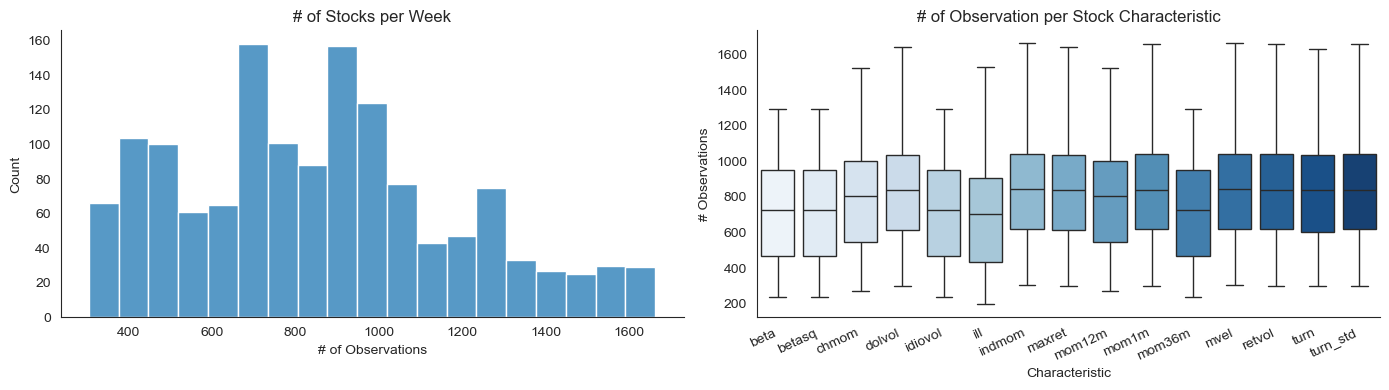

In [19]:
with sns.axes_style("white"):
    fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
    sns.histplot(nobs_by_date, ax=axes[0])
    axes[0].set_title("# of Stocks per Week")
    axes[0].set_xlabel("# of Observations")
    sns.boxplot(
        x="Characteristic",
        y="# Observations",
        data=nobs_by_characteristic,
        ax=axes[1],
        palette="Blues",
    )
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha="right")
    axes[1].set_title("# of Observation per Stock Characteristic")
    sns.despine()
    fig.tight_layout()

### Rank-normalize characteristics

In [15]:
data.loc[:, characteristics] = (
    data.loc[:, characteristics]
    .groupby(level="date")
    .apply(
        lambda x: pd.DataFrame(
            quantile_transform(x, copy=True, n_quantiles=x.shape[0]),
            columns=characteristics,
            index=x.index.get_level_values("ticker"),
        )
    )
    .mul(2)
    .sub(1)
)

Exception ignored in: <function _xla_gc_callback at 0x0000019530CBC790>
Traceback (most recent call last):
  File "c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\jax\_src\lib\__init__.py", line 128, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


In [21]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2343420 entries, (Timestamp('1993-01-01 00:00:00'), 'AAL') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 17 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   returns      1208156 non-null  float64
 1   beta         1021992 non-null  float64
 2   betasq       1021992 non-null  float64
 3   chmom        1141228 non-null  float64
 4   dolvol       1197840 non-null  float64
 5   idiovol      1021992 non-null  float64
 6   ill          1000373 non-null  float64
 7   indmom       1208156 non-null  float64
 8   maxret       1197840 non-null  float64
 9   mom12m       1141228 non-null  float64
 10  mom1m        1203484 non-null  float64
 11  mom36m       1021243 non-null  float64
 12  mvel         1209512 non-null  float64
 13  retvol       1203484 non-null  float64
 14  turn         1192041 non-null  float64
 15  turn_std     1203844 non-null  float64
 16  returns_fwd  12

In [22]:
data.index.names

FrozenList(['date', 'ticker'])

In [23]:
data.describe()

,returns,beta,betasq,chmom,dolvol,idiovol,ill,indmom,maxret,mom12m,mom1m,mom36m,mvel,retvol,turn,turn_std,returns_fwd
count,1.208156e+06,1.021992e+06,1.021992e+06,1.141228e+06,1.197840e+06,1.021992e+06,1.000373e+06,1.208156e+06,1.197840e+06,1.141228e+06,1.203484e+06,1.021243e+06,1.209512e+06,1.203484e+06,1.192041e+06,1.203844e+06,1.207850e+06
mean,3.384627e-03,-1.063869e-07,-2.425473e-06,6.412922e-08,-1.500696e-05,-6.816388e-07,-3.394576e-06,-3.989337e-04,-4.144560e-07,-6.889286e-07,-8.532240e-08,-1.066165e-06,-2.484961e-07,-5.077620e-06,-8.857910e-06,-1.857620e-05,3.381365e-03
std,7.243071e-02,5.781446e-01,5.781474e-01,5.780603e-01,5.780546e-01,5.781447e-01,5.781624e-01,6.126864e-01,5.780260e-01,5.780610e-01,5.780174e-01,5.781449e-01,5.780209e-01,5.780317e-01,5.780429e-01,5.780533e-01,7.243362e-02
min,-9.500000e-01,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-9.500000e-01
25%,-2.662221e-02,-5.006443e-01,-5.006468e-01,-5.005453e-01,-5.005039e-01,-5.006822e-01,-5.005489e-01,-4.924744e-01,-5.005620e-01,-5.005398e-01,-5.004997e-01,-5.006832e-01,-5.005217e-01,-5.005076e-01,-5.005639e-01,-5.005093e-01,-2.662650e-02
50%,0.000000e+00,1.147931e-05,5.043566e-06,7.829109e-06,-2.424204e-05,2.051827e-05,1.778424e-05,-7.826610e-03,2.979405e-05,-1.556521e-07,3.463442e-05,2.271459e-05,1.415396e-05,2.190525e-05,4.707301e-06,-1.006703e-05,0.000000e+00
75%,2.924448e-02,5.006242e-01,5.006226e-01,5.005872e-01,5.005453e-01,5.006540e-01,5.006204e-01,4.852498e-01,5.004917e-01,5.005664e-01,5.005097e-01,5.006246e-01,5.005109e-01,5.005041e-01,5.005096e-01,5.005258e-01,2.923989e-02
max,2.833333e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.833333e+00


In [24]:
data = data.loc[idx[:"2019", :], :]

In [25]:
data.loc[:, ["returns", "returns_fwd"]] = data.loc[:, ["returns", "returns_fwd"]].clip(
    lower=-1, upper=1.0
)

In [26]:
data = data.fillna(-2)

In [27]:
data.to_hdf(results_path / "autoencoder.h5", "model_data")

## Architecture

In [16]:
data = pd.read_hdf(results_path / "autoencoder.h5", "model_data")

### Key parameters

In [17]:
n_factors = 3
n_characteristics = len(characteristics)
n_tickers = len(data.index.unique("ticker"))

In [18]:
n_tickers

1662

In [19]:
n_characteristics

15

### Input Layer

In [32]:
input_beta = Input((n_tickers, n_characteristics), name="input_beta")
input_factor = Input((n_tickers,), name="input_factor")

### Stock Characteristics Network

In [33]:
hidden_layer = Dense(units=8, activation="relu", name="hidden_layer")(input_beta)
batch_norm = BatchNormalization(name="batch_norm")(hidden_layer)
output_beta = Dense(units=n_factors, name="output_beta")(batch_norm)

### Factor Network

In [34]:
output_factor = Dense(units=n_factors, name="output_factor")(input_factor)

### Output Layer

In [35]:
output = Dot(axes=(2, 1), name="output_layer")([output_beta, output_factor])

### Compile Layer

In [36]:
model = Model(inputs=[input_beta, input_factor], outputs=output)
model.compile(loss="mse", optimizer="adam")

### Automate model generation

In [34]:
def make_model(hidden_units=8, n_factors=3):
    input_beta = Input((n_tickers, n_characteristics), name="input_beta")
    input_factor = Input((n_tickers,), name="input_factor")

    hidden_layer = Dense(units=hidden_units, activation="relu", name="hidden_layer")(
        input_beta
    )
    batch_norm = BatchNormalization(name="batch_norm")(hidden_layer)

    output_beta = Dense(units=n_factors, name="output_beta")(batch_norm)

    output_factor = Dense(units=n_factors, name="output_factor")(input_factor)

    output = Dot(axes=(2, 1), name="output_layer")([output_beta, output_factor])

    model = Model(inputs=[input_beta, input_factor], outputs=output)
    model.compile(loss="mse", optimizer="adam")
    return model

### Model Summary

In [38]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_beta          │ (None, 1662, 15)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer        │ (None, 1662, 8)   │        128 │ input_beta[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm          │ (None, 1662, 8)   │         32 │ hidden_layer[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_factor        │ (None, 1662)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_beta (Dense) │ (None, 1662, 3)   │         27 │ batch_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_factor       │ (None, 3)         │      4,989 │ input_factor[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer (Dot)  │ (None, 1662)      │          0 │ output_beta[0][0… │
│                     │                   │            │ output_factor[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,176 (20.22 KB)

 Trainable params: 5,160 (20.16 KB)

 Non-trainable params: 16 (64.00 B)

## Train Model

### Cross-validation parameters

In [35]:
YEAR = 52

In [36]:
cv = MultipleTimeSeriesCV(
    n_splits=5, train_period_length=20 * YEAR, test_period_length=1 * YEAR, lookahead=1
)

In [37]:
def get_train_valid_data(data, train_idx, val_idx):
    train, val = data.iloc[train_idx], data.iloc[val_idx]
    X1_train = train.loc[:, characteristics].values.reshape(
        -1, n_tickers, n_characteristics
    )
    X1_val = val.loc[:, characteristics].values.reshape(
        -1, n_tickers, n_characteristics
    )
    X2_train = train.loc[:, "returns"].unstack("ticker")
    X2_val = val.loc[:, "returns"].unstack("ticker")
    y_train = train.returns_fwd.unstack("ticker")
    y_val = val.returns_fwd.unstack("ticker")
    return X1_train, X2_train, y_train, X1_val, X2_val, y_val

### Hyperparameter Options

In [42]:
factor_opts = [2, 3, 4, 5, 6]
unit_opts = [8, 16, 32]

In [43]:
param_grid = list(product(unit_opts, factor_opts))

### Run Cross-Validation

In [44]:
batch_size = 32

In [38]:
cols = [
    "units",
    "n_factors",
    "fold",
    "epoch",
    "ic_mean",
    "ic_daily_mean",
    "ic_daily_std",
    "ic_daily_median",
]

In [46]:
start = time()
for units, n_factors in param_grid:
    scores = []
    model = make_model(hidden_units=units, n_factors=n_factors)
    for fold, (train_idx, val_idx) in enumerate(cv.split(data)):
        X1_train, X2_train, y_train, X1_val, X2_val, y_val = get_train_valid_data(
            data, train_idx, val_idx
        )
        for epoch in range(250):
            model.fit(
                [X1_train, X2_train],
                y_train,
                batch_size=batch_size,
                validation_data=([X1_val, X2_val], y_val),
                epochs=epoch + 1,
                initial_epoch=epoch,
                verbose=0,
                shuffle=True,
            )
            result = (
                pd.DataFrame(
                    {
                        "y_pred": model.predict([X1_val, X2_val]).reshape(-1),
                        "y_true": y_val.stack().values,
                    },
                    index=y_val.stack().index,
                )
                .replace(-2, np.nan)
                .dropna()
            )
            r0 = spearmanr(result.y_true, result.y_pred)[0]
            r1 = result.groupby(level="date").apply(
                lambda x: spearmanr(x.y_pred, x.y_true)[0]
            )

            scores.append(
                [units, n_factors, fold, epoch, r0, r1.mean(), r1.std(), r1.median()]
            )
            if epoch % 50 == 0:
                print(
                    f"{format_time(time() - start)} | {n_factors} | {units:02} | {fold:02}-{epoch:03} | {r0:6.2%} | "
                    f"{r1.mean():6.2%} | {r1.median():6.2%}"
                )
    scores = pd.DataFrame(scores, columns=cols)
    scores.to_hdf(results_path / "scores.h5", f"{units}/{n_factors}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
00:00:03 | 2 | 08 | 00-000 | -4.19% | -4.44% | -5.24%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/s

### Evaluate Results

In [20]:
scores = []
with pd.HDFStore(results_path / "scores.h5") as store:
    for key in store.keys():
        scores.append(store[key])
scores = pd.concat(scores)

In [21]:
scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18750 entries, 0 to 1249
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   units            18750 non-null  int64  
 1   n_factors        18750 non-null  int64  
 2   fold             18750 non-null  int64  
 3   epoch            18750 non-null  int64  
 4   ic_mean          18750 non-null  float64
 5   ic_daily_mean    18750 non-null  float64
 6   ic_daily_std     18750 non-null  float64
 7   ic_daily_median  18750 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 1.3 MB


In [24]:
scores.reset_index(inplace=True, drop=True)

In [26]:
scores

,units,n_factors,fold,epoch,ic_mean,ic_daily_mean,ic_daily_std,ic_daily_median
0,8,2,0,0,-0.041854,-0.044421,0.084266,-0.052400
1,8,2,0,1,-0.038899,-0.039251,0.077403,-0.049987
2,8,2,0,2,-0.025217,-0.021720,0.072673,-0.027794
3,8,2,0,3,-0.012483,-0.007962,0.078267,-0.018200
4,8,2,0,4,-0.007043,-0.002679,0.079122,-0.003961
...,...,...,...,...,...,...,...,...
18745,16,6,4,245,0.033785,0.027940,0.092667,0.024247
18746,16,6,4,246,0.009558,0.006654,0.104166,0.007704
18747,16,6,4,247,0.013472,-0.004031,0.163854,-0.002935
18748,16,6,4,248,0.040462,0.037263,0.098652,0.049389


In [27]:
avg = (
    scores.groupby(["n_factors", "units", "epoch"])[
        ["ic_mean", "ic_daily_mean", "ic_daily_median"]
    ]
    .mean()
    .reset_index()
)

In [28]:
avg.nlargest(n=20, columns=["ic_daily_median"])

,n_factors,units,epoch,ic_mean,ic_daily_mean,ic_daily_median
3263,6,16,13,0.041656,0.037656,0.041250
3374,6,16,124,0.030608,0.027072,0.033102
25,2,8,25,0.026533,0.024293,0.031723
3426,6,16,176,0.028491,0.024135,0.031113
3262,6,16,12,0.034529,0.024822,0.030291
3282,6,16,32,0.021256,0.023263,0.029977
3295,6,16,45,0.027543,0.022964,0.028618
1758,4,16,8,0.038529,0.028024,0.028268
3421,6,16,171,0.025280,0.020154,0.027938
3495,6,16,245,0.024978,0.021055,0.027756


In [29]:
top = (
    avg.groupby(["n_factors", "units"])
    .apply(lambda x: x.nlargest(n=5, columns=["ic_daily_median"]))
    .reset_index(-1, drop=True)
)

top.nlargest(n=5, columns=["ic_daily_median"])

n_factors  units  epoch   ic_mean  ic_daily_mean  \
n_factors units                                                     
6         16             6     16     13  0.041656       0.037656   
          16             6     16    124  0.030608       0.027072   
2         8              2      8     25  0.026533       0.024293   
6         16             6     16    176  0.028491       0.024135   
          16             6     16     12  0.034529       0.024822   

                 ic_daily_median  
n_factors units                   
6         16            0.041250  
          16            0.033102  
2         8             0.031723  
6         16            0.031113  
          16            0.030291

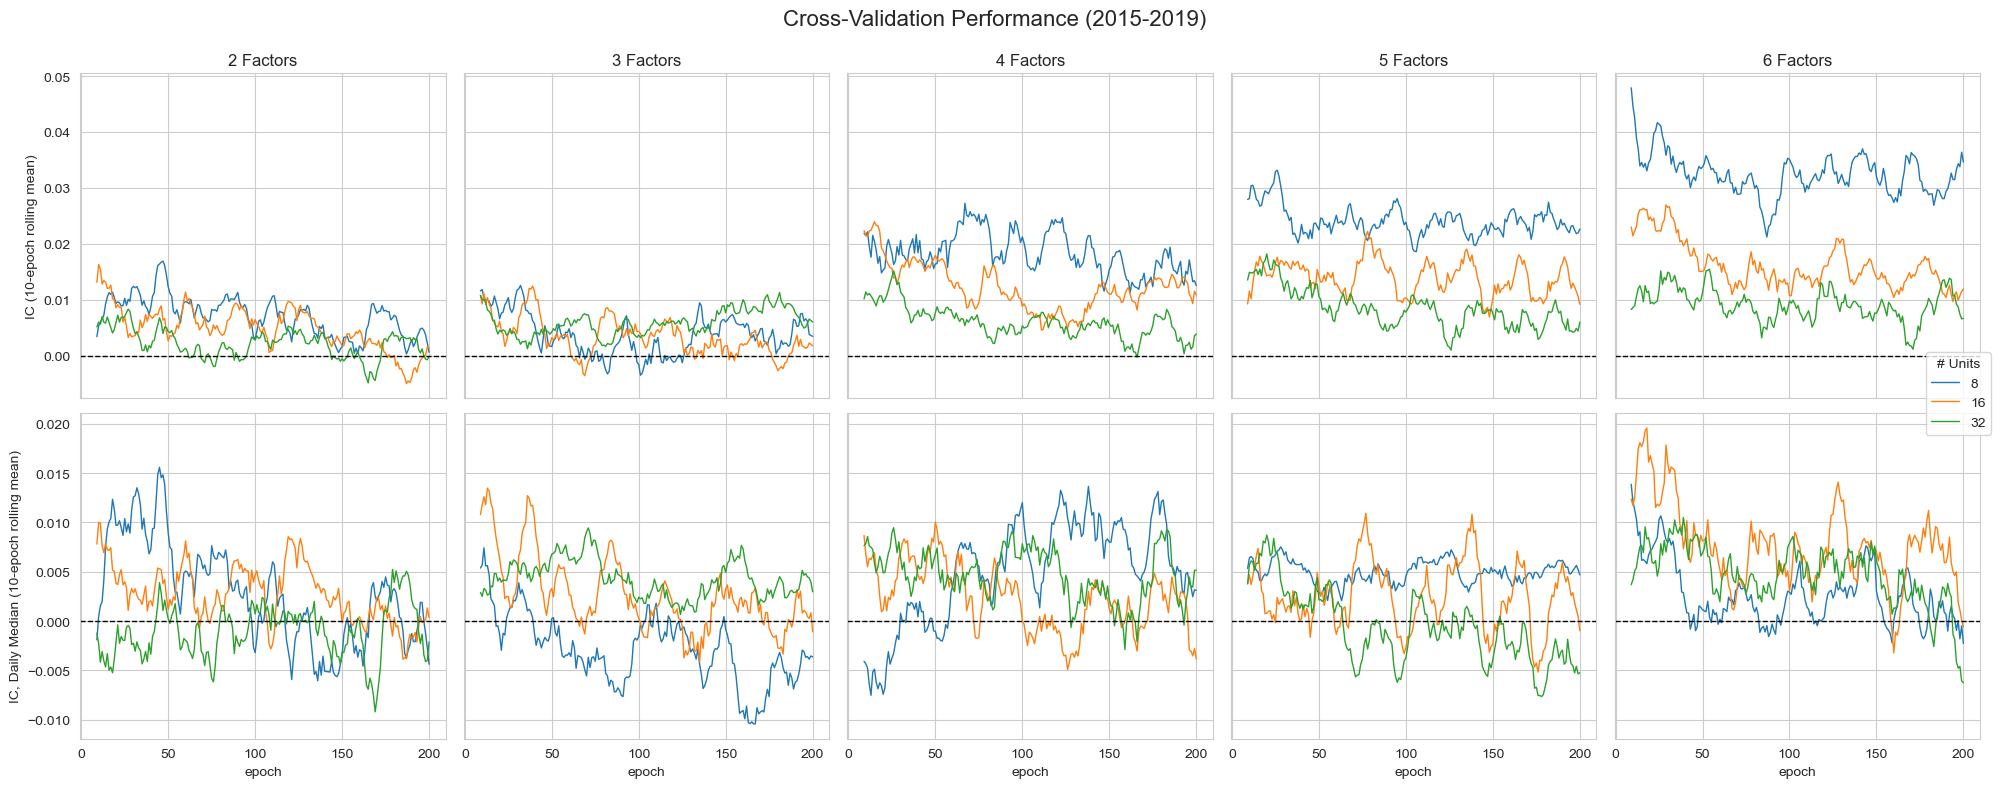

In [30]:
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=(20, 8), sharey="row", sharex=True)

for n in range(2, 7):
    df = avg[avg.n_factors == n].pivot(index="epoch", columns="units", values="ic_mean")
    df.rolling(10).mean().loc[:200].plot(ax=axes[0][n - 2], lw=1, title=f"{n} Factors")
    axes[0][n - 2].axhline(0, ls="--", c="k", lw=1)
    axes[0][n - 2].get_legend().remove()
    axes[0][n - 2].set_ylabel("IC (10-epoch rolling mean)")

    df = avg[avg.n_factors == n].pivot(
        index="epoch", columns="units", values="ic_daily_median"
    )
    df.rolling(10).mean().loc[:200].plot(ax=axes[1][n - 2], lw=1)
    axes[1][n - 2].axhline(0, ls="--", c="k", lw=1)
    axes[1][n - 2].get_legend().remove()
    axes[1][n - 2].set_ylabel("IC, Daily Median (10-epoch rolling mean)")

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="# Units")
fig.suptitle("Cross-Validation Performance (2015-2019)", fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.savefig(results_path / "cv_performance", dpi=300);

## Generate Predictions

We'll average over a range of epochs that appears to deliver good predictions.

In [31]:
n_factors = 5
units = 8
batch_size = 32
first_epoch = 1
last_epoch = 200

In [41]:
predictions = []

# Create base model just for architecture reference
base_model = make_model(n_factors=n_factors, hidden_units=units)

for epoch in tqdm(list(range(first_epoch, last_epoch))):
    epoch_preds = []
    for fold, (train_idx, val_idx) in enumerate(cv.split(data)):
        X1_train, X2_train, y_train, X1_val, X2_val, y_val = get_train_valid_data(
            data, train_idx, val_idx
        )

        # Clone the model architecture
        model = tf.keras.models.clone_model(base_model)
        
        # Simple compilation matching your make_model function
        model.compile(loss="mse", optimizer="adam")
        
        model.fit(
            [X1_train, X2_train],
            y_train,
            batch_size=batch_size,
            epochs=epoch,
            verbose=0,
            shuffle=True,
        )
        
        epoch_preds.append(
            pd.Series(
                model.predict([X1_val, X2_val]).reshape(-1), 
                index=y_val.stack().index
            ).to_frame(epoch)
        )

    predictions.append(pd.concat(epoch_preds))

  0%|          | 0/199 [00:00<?, ?it/s]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


  1%|          | 1/199 [00:09<31:40,  9.60s/it]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


  1%|          | 2/199 [00:19<33:02, 10.06s/it]

...

 99%|█████████▉| 197/199 [8:44:06<09:42, 291.29s/it]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


 99%|█████████▉| 198/199 [8:49:17<04:57, 297.05s/it]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


100%|██████████| 199/199 [8:54:47<00:00, 161.24s/it]


In [42]:
predictions_combined = pd.concat(predictions, axis=1).sort_index()

In [43]:
predictions_combined.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 432120 entries, (Timestamp('2015-01-09 00:00:00'), 'AAL') to (Timestamp('2019-12-27 00:00:00'), 'ZYXI')
Columns: 199 entries, 1 to 199
dtypes: float32(199)
memory usage: 329.8+ MB


In [46]:
predictions_combined.to_hdf(results_path / "predictions.h5", "predictions")